(1709, 1709, 3)


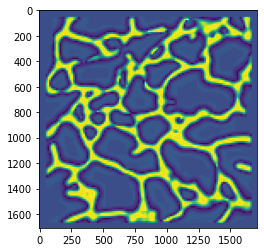

In [3]:
import cv2
import sknw
from skimage.morphology import skeletonize
import networkx as nx
import json
import matplotlib.pyplot as plt
import collections
from skimage import io
import numpy as np

import imageio

# plt.switch_backend("agg")

import imageio

import sknw
import numpy as np


img = imageio.imread('comparison_figures/climp1_er_mean.png')
binimg = imageio.imread('/localhome/asa420/Downloads/ERnet-v2-main/images/climp1_er_mean_proc_enhance.png')

gt_skel = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/Climp/climp1_proc_skel.png')

skel = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/Climp/climp1_er_mean_proc_enhance_skel.png')

analyzer_input = imageio.imread('comparison_figures/processed data/images/ER_er_ip.png')

analyzer_skel = imageio.imread('comparison_figures/processed data/images/ER_skele_bin.png')

analyzer_enh = imageio.imread('comparison_figures/processed data/images/ER_enh.png')

print(analyzer_enh.shape)



plt.imshow(analyzer_enh[:,:,0])



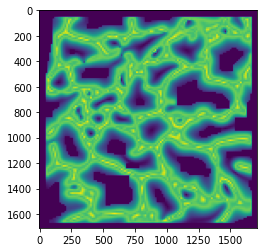

In [4]:
plt.imshow(analyzer_enh[:,:,1])

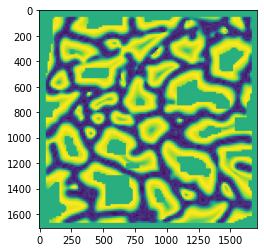

In [5]:
plt.imshow(analyzer_enh[:,:,2])

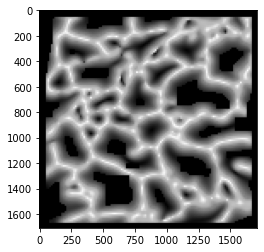

In [7]:
from skimage import color

out = color.rgb2gray(analyzer_enh)

plt.imshow(out, cmap='gray')

In [ ]:
print(analyzer_input.shape)

# if analyzer_skel[:,:,0].all() == analyzer_skel[:,:,1].all() == analyzer_skel[:,:,2].all() == analyzer_skel[:,:,3].all():
#     print('yes')

# exit()

# fig, ax = plt.subplots(1, 4, figsize=(15, 15))

# ax[0].imshow(analyzer_skel[:,:,0], cmap='gray')
# ax[1].imshow(analyzer_skel[:,:,1], cmap='gray')
# ax[2].imshow(analyzer_skel[:,:,2], cmap='gray')
# ax[3].imshow(analyzer_skel[:,:,3], cmap='gray')
er = analyzer_input[:,:,1]

er = er[32:er.shape[0]-26, 32:er.shape[0]-26]

op = analyzer_skel[:,:,0]


plt.imshow(er, cmap='gray')
# plt.show()

# exit()

op[np.where(op > 0)] = 1

skel = skeletonize(op).astype(np.uint16)

# graph = sknw.build_sknw(gt_skel, multi=False, iso=False)
graph = sknw.build_sknw(skel, multi=False, iso=False)

# draw image
import matplotlib.pyplot as plt
plt.imshow(er, cmap='gray')
# plt.imshow(binimg, cmap='gray')

# draw edges by pts
for (s,e) in graph.edges():
    ps = graph[s][e]['pts']
    plt.plot(ps[:,1], ps[:,0], 'green')

# draw node by o
nodes = graph.nodes()
ps = np.array([nodes[i]['o'] for i in nodes])


plt.plot(ps[:,1], ps[:,0], 'r.', markersize=2.5)

plt.axis('off')

# plt.savefig('climp1_analyzer_graph.png', bbox_inches='tight', pad_inches=0, dpi=300)

# plt.close()






In [ ]:
def remove_isolated_pixels(image):
    connectivity = 8

    output = cv2.connectedComponentsWithStats(image, connectivity, cv2.CV_32S)

    num_stats = output[0]
    labels = output[1]
    stats = output[2]

    new_image = image.copy()

    for label in range(num_stats):
        if stats[label, cv2.CC_STAT_AREA] < 50:
            new_image[labels == label] = 0

    return new_image


def binariseImage(I):
    if len(I.shape) > 2:
        ind = I[:, :, 0] > 250
    else:
        ind = I > 250
    Ibin = np.zeros((I.shape[0], I.shape[1])).astype("uint8")
    Ibin[ind] = 255
    Ibin = remove_isolated_pixels(Ibin)
    return Ibin


def getGraph():
    # opimg = img
    # plt.imshow(img, cmap="gray")
    # img = binariseImage(img) / 255
    img = imageio.imread('comparison_figures/climp1_er_mean_out_ERNet.png') / 255
    ske = skeletonize(img).astype(np.uint16)
    # ske = img.astype('uint16')

    # build graph from skeleton
    graph = sknw.build_sknw(ske)

    # draw image
    # plt.figure(figsize=(15, 15))
    plt.imshow(img, cmap="gray")

    # draw edges by pts
    for s, e in graph.edges():
        ps = graph[s][e]["pts"]
        plt.plot([ps[0, 1], ps[-1, 1]], [ps[0, 0], ps[-1, 0]], "green")

    # draw node by o
    nodes = graph.nodes()
    ps = np.array([nodes[i]["o"] for i in nodes])
    plt.plot(ps[:, 1], ps[:, 0], "r.", markersize=2)

    plt.axis("off")

    plt.savefig('climp1_er_mean_out_ERNet_graph.png', bbox_inches='tight', pad_inches=0, dpi=300)

    plt.close()

    # plt.savefig("%s_fig_graph.jpg" % basename, bbox_inches="tight", pad_inches=0, dpi=300)
    # plt.close()
    # open("%s_edges.dat" % basename, "w").write(
    #     str(graph.edges()).replace("(", "[").replace(")", "]")
    # )
    # open("%s_nodes.dat" % basename, "w").write(
    #     str(graph.nodes()).replace("(", "[").replace(")", "]")
    # )

    # edges = np.array(graph.edges())

    # return edges, nodes





# getGraph()


# exit()

# img = imageio.imread('comparison_figures/processed data/images/ER_skele.png')

# data = img[:,:,0]

# data = data[32:data.shape[0]-26, 32:data.shape[0]-26]

# print(data.shape)

# # exit()

# plt.axis('off')
# plt.imshow(data, cmap='gray')
# # plt.show()

# plt.savefig('comparison_figures/processed data/images/ER_skele_bin.png', bbox_inches='tight', pad_inches=0, dpi=300)

# plt.close()

# exit()


In [8]:
er = imageio.imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/ER_im1.png')

sk = imageio.imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/ER_sk1.png')

In [9]:
er.shape

(1709, 1759, 3)

In [10]:
sk.shape

(1709, 1709, 3)

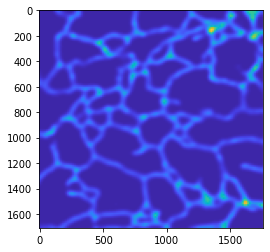

In [12]:
plt.imshow(er)

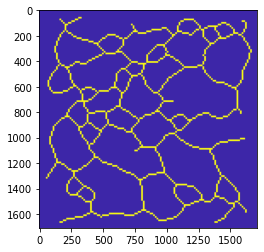

In [13]:
plt.imshow(sk)

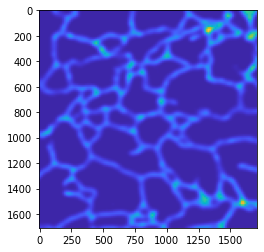

In [14]:
erop = er[:,25:er.shape[1]-25]
plt.imshow(erop)

In [15]:
erop.shape

(1709, 1709, 3)

In [17]:
mshow = plt.imshow

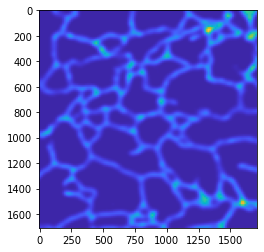

In [18]:
mshow(erop)

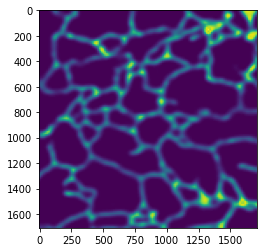

In [23]:
mshow(erop[:,:,1])

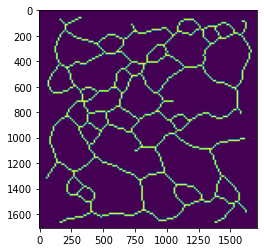

In [25]:
mshow(sk[:,:,1])

In [26]:
skop = sk[:,:,0]

skop[np.where(skop > 0)] = 1

skel = skeletonize(skop).astype(np.uint16)


In [27]:
graph = sknw.build_sknw(skel, multi=False, iso=False)

In [30]:
graph.edges()

EdgeView([(0, 1)])

In [33]:
erop[:,:,1].shape

(1709, 1709)

In [34]:
skel.shape

(1108, 1108)

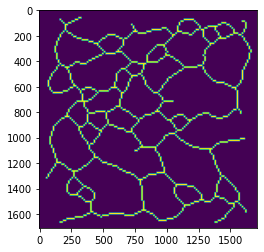

In [62]:
analyzer_skel = imageio.imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/ER_sk1.png')

# analyzer_skel[np.where(analyzer_skel[:,:,0]>0)] = 1

nskel = analyzer_skel[:,:,0].astype(np.uint16)

np.unique(nskel)
# mshow(nskel)

nskel[np.where(nskel==max(np.unique(nskel)))] = 255.

# np.where(nskel > 0)
mshow(nskel)

(-0.5, 1708.5, 1708.5, -0.5)

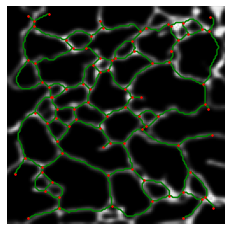

In [90]:
analyzer_skel = imageio.imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/ER_sk1.png')


op = analyzer_skel[:,:,0]

mval = min(np.unique(op))

op[np.where(op==mval)] = 0
op[np.where(op!=mval) and np.where(op!=0)] = 255

op = op/255
np.unique(op)

an_skel = skeletonize(op).astype(np.uint16)

# mshow(skel)

# graph = sknw.build_sknw(gt_skel, multi=False, iso=False)
graph = sknw.build_sknw(an_skel, multi=False, iso=False)

# draw image
plt.imshow(erop[:,:,1], cmap='gray')
# plt.imshow(binimg, cmap='gray')

# draw edges by pts
for (s,e) in graph.edges():
    ps = graph[s][e]['pts']
    plt.plot(ps[:,1], ps[:,0], 'green')

# draw node by o
nodes = graph.nodes()
ps = np.array([nodes[i]['o'] for i in nodes])


plt.plot(ps[:,1], ps[:,0], 'r.', markersize=3)

plt.axis('off')

# plt.savefig('climp1_analyzer_graph.png', bbox_inches='tight', pad_inches=0, dpi=300)

# plt.close()

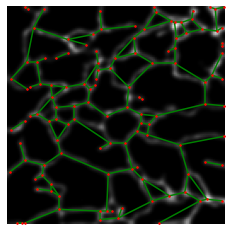

In [88]:
def remove_isolated_pixels(image):
    connectivity = 8

    output = cv2.connectedComponentsWithStats(image, connectivity, cv2.CV_32S)

    num_stats = output[0]
    labels = output[1]
    stats = output[2]

    new_image = image.copy()

    for label in range(num_stats):
        if stats[label, cv2.CC_STAT_AREA] < 50:
            new_image[labels == label] = 0

    return new_image


def binariseImage(I):
    if len(I.shape) > 2:
        ind = I[:, :, 0] > 250
    else:
        ind = I > 250
    Ibin = np.zeros((I.shape[0], I.shape[1])).astype("uint8")
    Ibin[ind] = 255
    Ibin = remove_isolated_pixels(Ibin)
    return Ibin


def getGraph():
    # opimg = img
    # plt.imshow(img, cmap="gray")
    # img = binariseImage(img) / 255
    er = imageio.imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/climp1_er_mean.png')
    img = imageio.imread('comparison_figures/climp1_er_mean_out_ERNet.png') / 255
    ske = skeletonize(img).astype(np.uint16)
    # ske = img.astype('uint16')

    # build graph from skeleton
    graph = sknw.build_sknw(ske)

    # draw image
    # plt.figure(figsize=(15, 15))
    plt.imshow(er, cmap="gray")

    # draw edges by pts
    for s, e in graph.edges():
        ps = graph[s][e]["pts"]
        plt.plot([ps[0, 1], ps[-1, 1]], [ps[0, 0], ps[-1, 0]], "green")

    # draw node by o
    nodes = graph.nodes()
    ps = np.array([nodes[i]["o"] for i in nodes])
    plt.plot(ps[:, 1], ps[:, 0], "r.", markersize=3)

    plt.axis("off")

#     plt.savefig('climp1_er_mean_out_ERNet_graph-v2.png', bbox_inches='tight', pad_inches=0, dpi=300)

#     plt.close()

    # plt.savefig("%s_fig_graph.jpg" % basename, bbox_inches="tight", pad_inches=0, dpi=300)
    # plt.close()
    # open("%s_edges.dat" % basename, "w").write(
    #     str(graph.edges()).replace("(", "[").replace(")", "]")
    # )
    # open("%s_nodes.dat" % basename, "w").write(
    #     str(graph.nodes()).replace("(", "[").replace(")", "]")
    # )

    # edges = np.array(graph.edges())

    # return edges, nodes





getGraph()

In [132]:
# perform some analysis
def simple_analysis(G):
    no_nodes = G.number_of_nodes()
    no_edges = G.number_of_edges()
    assortativity = nx.degree_assortativity_coefficient(G)
    clustering = nx.average_clustering(G)
    compo = nx.number_connected_components(G)
    Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
    G0 = G.subgraph(Gcc[0])
    size_G0_edges = G0.number_of_edges()
    size_G0_nodes = G0.number_of_nodes()
    ratio_nodes = size_G0_nodes / no_nodes
    ratio_edges = size_G0_edges / no_edges
    return [
        no_nodes,
        no_edges,
        assortativity,
        clustering,
        compo
    ]


# here we generate a histogram of degrees with a specified colour
def degree_histogram(savepath, G, colour="blue"):
    plt.figure()

    degree_sequence = sorted(
        [d for n, d in G.degree()], reverse=True
    )  # degree sequence
    degreeCount = collections.Counter(degree_sequence)
    deg, cnt = zip(*degreeCount.items())
    fig1, ax = plt.subplots()
    plt.bar(deg, cnt, width=0.80, color=colour)
    plt.ylabel("Count")
    plt.xlabel("%Degree")
    ax.set_xticks([d + 0.4 for d in deg])
    ax.set_xticklabels(deg)
    plt.savefig(savepath)
    plt.close()

    degrees = [0] * 6  # ordered from deg. 1 to 6
    for _deg, _cnt in zip(deg, cnt):
        if _deg - 1 < 6:
            degrees[_deg - 1] = _cnt

    return degrees


def graph_image(savepath, G):
    # here we generate an image where nodes are coloured according to their degrees
    plt.figure()
    node_color = [float(G.degree(v)) for v in G]
    nx.draw_spring(G, node_size=10, node_color=node_color)
    plt.savefig(savepath)

    plt.close()



In [94]:
def remove_isolated_pixels(image):
    connectivity = 8

    output = cv2.connectedComponentsWithStats(image, connectivity, cv2.CV_32S)

    num_stats = output[0]
    labels = output[1]
    stats = output[2]

    new_image = image.copy()

    for label in range(num_stats):
        if stats[label, cv2.CC_STAT_AREA] < 50:
            new_image[labels == label] = 0

    return new_image


def binariseImage(I):
    if len(I.shape) > 2:
        ind = I[:, :, 0] > 250
    else:
        ind = I > 250
    Ibin = np.zeros((I.shape[0], I.shape[1])).astype("uint8")
    Ibin[ind] = 255
    Ibin = remove_isolated_pixels(Ibin)
    return Ibin

In [150]:
# GT graph
def get_graph(skel):
    gt_skel = imageio.imread(skel)
    gt_graph = sknw.build_sknw(gt_skel, multi=False, iso=False)
    return gt_graph

# analyzer graph
def get_analyzer_graph(analyzer_skel):
#     analyzer_skel = imageio.imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/ER_sk1.png')
    op = analyzer_skel[:,:,0]
    mval = min(np.unique(op))
    op[np.where(op==mval)] = 0
    op[np.where(op!=mval) and np.where(op!=0)] = 255
    op = op/255
    an_skel = skeletonize(op).astype(np.uint16)
    analyzer_graph = sknw.build_sknw(an_skel, multi=False, iso=False)
    return analyzer_graph

#ernet graph
def get_ernet_graph(enh):
#     ernet_enh = imageio.imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/climp1_er_mean_out_ERNet.png') / 255.
    ernet_skel = skeletonize(enh).astype(np.uint16)
    ernet_graph = sknw.build_sknw(ernet_skel)
    return ernet_graph

# def get_dyner_graph():
#     dyner_skel = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/Climp/climp1_er_mean_proc_enhance_skel.png')
#     dyner_graph = sknw.build_sknw(dyner_skel, multi=False, iso=False)
#     return dyner_graph

In [98]:
gt_data = simple_analysis(gt_graph)

In [108]:
skel = imageio.imread(f'/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/analyzER-skel/ER_atl{i}.png')
g = get_analyzer_graph(skel)

In [109]:
g

In [146]:
def get_analyzer_graph_metrics(group):
    analysis_r1 = []
    analysis_r2 = []
    analysis_r3 = []
    for i in range(1, 11):
        try:
            skel = imageio.imread(f'/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/analyzER-skel/ER_{group.lower()}{i}.png')
            graph = get_analyzer_graph(skel)
            analysis_r1.append(simple_analysis(graph))
        except:
            pass
    analysis_r1 = np.array(analysis_r1)
    for i in range(11, 21):
        skel = imageio.imread(f'/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/analyzER-skel/ER_{group.lower()}{i}.png')
        graph = get_analyzer_graph(skel)
        analysis_r2.append(simple_analysis(graph))
    analysis_r2 = np.array(analysis_r2)
    for i in range(21, 32):
        try:
            skel = imageio.imread(f'/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/analyzER-skel/ER_{group.lower()}{i}.png')
            graph = get_analyzer_graph(skel)
            analysis_r3.append(simple_analysis(graph))
        except:
            pass
    analysis_r3 = np.array(analysis_r3)
    
    return analysis_r1, analysis_r2, analysis_r3

In [147]:
atl_r1, atl_r2, atl_r3 = get_analyzer_graph_metrics('ATL')
climp_r1, climp_r2, climp_r3 = get_analyzer_graph_metrics('Climp')
control_r1, control_r2, control_r3 = get_analyzer_graph_metrics('Control')
rtn_r1, rtn_r2, rtn_r3 = get_analyzer_graph_metrics('RTN')

def get_graph_metric_mean(r1,r2,r3):
    data = []
    for feature_num in range(5):
        d = []
        d.append(np.mean(r1[:,feature_num]))
        d.append(np.mean(r2[:,feature_num]))
        d.append(np.mean(r3[:,feature_num]))
        data.append(d)
    return data

# atl = get_graph_metric_mean(atl_r1, atl_r2, atl_r3)
# climp = get_graph_metric_mean(climp_r1, climp_r2, climp_r3)
# control = get_graph_metric_mean(control_r1, control_r2, control_r3)
rtn = get_graph_metric_mean(rtn_r1, rtn_r2, rtn_r3)

In [140]:
atl

[[118.8, 80.1, 118.66666666666667],
 [161.7, 102.9, 156.16666666666666],
 [-0.05575978589255761, -0.0474518600582916, -0.04323164229015856],
 [0.04287868180462454, 0.04327088598230424, 0.03739835286451904],
 [1.0, 1.4, 1.0]]

In [141]:
climp

[[65.8, 59.4, 75.63636363636364],
 [83.3, 74.1, 96.0],
 [-0.08144264740931323, -0.11001810480036363, -0.05233215332787029],
 [0.03063036832836355, 0.04590183056201362, 0.046815681647627436],
 [1.0, 1.0, 1.0]]

In [142]:
control

[[56.4, 65.3, 75.36363636363636],
 [68.8, 79.8, 93.45454545454545],
 [-0.12361936678854465, -0.14466052876960894, -0.11450618905139995],
 [0.034571353642935586, 0.040095413429479684, 0.02201613464649138],
 [1.0, 1.0, 1.0]]

In [148]:
rtn

[[97.88888888888889, 96.8, 88.33333333333333],
 [123.88888888888889, 123.6, 113.44444444444444],
 [-0.07803565495936744, -0.044055349258242484, -0.0497732700812637],
 [0.05460941408700749, 0.05294245155293533, 0.05992706830023458],
 [1.0, 1.0, 1.0]]

In [151]:
def get_ernet_graph_metrics(group):
    analysis_r1 = []
    analysis_r2 = []
    analysis_r3 = []
    for i in range(1, 11):
        try:
            enh = imageio.imread(f'/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/ERNet-enh/{group.lower()}{i}_er_mean_out.png') / 255.
            graph = get_ernet_graph(enh)
            analysis_r1.append(simple_analysis(graph))
        except:
            pass
    analysis_r1 = np.array(analysis_r1)
    for i in range(11, 21):
        enh = imageio.imread(f'/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/ERNet-enh/{group.lower()}{i}_er_mean_out.png') / 255.
        graph = get_ernet_graph(enh)
        analysis_r2.append(simple_analysis(graph))
    analysis_r2 = np.array(analysis_r2)
    for i in range(21, 32):
        try:
            enh = imageio.imread(f'/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/comparison_figures/ERNet-enh/{group.lower()}{i}_er_mean_out.png') / 255.
            graph = get_ernet_graph(enh)
            analysis_r3.append(simple_analysis(graph))
        except:
            pass
    analysis_r3 = np.array(analysis_r3)
    
    return analysis_r1, analysis_r2, analysis_r3

In [152]:
a_r1, a_r2, a_r3 = get_ernet_graph_metrics('ATL')
c_r1, c_r2, c_r3 = get_analyzer_graph_metrics('Climp')
ct_r1, ct_r2, ct_r3 = get_analyzer_graph_metrics('Control')
r_r1, r_r2, r_r3 = get_analyzer_graph_metrics('RTN')

def get_graph_metric_mean(r1,r2,r3):
    data = []
    for feature_num in range(5):
        d = []
        d.append(np.mean(r1[:,feature_num]))
        d.append(np.mean(r2[:,feature_num]))
        d.append(np.mean(r3[:,feature_num]))
        data.append(d)
    return data

ernet_atl = get_graph_metric_mean(a_r1, a_r2, a_r3)
ernet_climp = get_graph_metric_mean(c_r1, c_r2, c_r3)
ernet_control = get_graph_metric_mean(ct_r1, ct_r2, ct_r3)
ernet_rtn = get_graph_metric_mean(r_r1, r_r2, r_r3)

In [153]:
ernet_atl

[[145.7, 151.5, 142.66666666666666],
 [181.0, 155.7, 179.16666666666666],
 [0.015683449541406463, 0.0999625311669109, -0.0059714369678961245],
 [0.05466608300212135, 0.0272728850866245, 0.045779578065960363],
 [6.9, 20.9, 7.333333333333333]]

In [154]:
ernet_climp

[[65.8, 59.4, 75.63636363636364],
 [83.3, 74.1, 96.0],
 [-0.08144264740931323, -0.11001810480036363, -0.05233215332787029],
 [0.03063036832836355, 0.04590183056201362, 0.046815681647627436],
 [1.0, 1.0, 1.0]]

In [155]:
ernet_control

[[56.4, 65.3, 75.36363636363636],
 [68.8, 79.8, 93.45454545454545],
 [-0.12361936678854465, -0.14466052876960894, -0.11450618905139995],
 [0.034571353642935586, 0.040095413429479684, 0.02201613464649138],
 [1.0, 1.0, 1.0]]

In [156]:
ernet_rtn

[[97.88888888888889, 96.8, 88.33333333333333],
 [123.88888888888889, 123.6, 113.44444444444444],
 [-0.07803565495936744, -0.044055349258242484, -0.0497732700812637],
 [0.05460941408700749, 0.05294245155293533, 0.05992706830023458],
 [1.0, 1.0, 1.0]]

In [189]:
erv2_atl = [[91, 77.5, 74.333], [91.4,72.3,74.667], [-0.243,-0.301,-0.224], [0.018,0.011,0.023], [7,8.9,5.667]]
erv2_climp = [[82.2, 69.3, 73.455], [86.9,71.7,75.455], [-0.175,-0.184,-0.171], [0.024,0.023,0.013], [4.8,4.7,4.636]]
erv2_rtn = [[71.1, 56.6, 87.889], [64.9,47.5,84], [-0.275,-0.37,-0.27], [0.011,0.012,0.019], [9.8,10.8,10.111]]
erv2_control = [[80.2, 73.9, 86.364], [85.6,78.2,87.273], [-0.188,-0.161,-0.206], [0.016,0.021,0.01], [4.3,5.1,5.545]]


dyner_atl = [[186.6,191.4,186.5], [221.4,207.5,214], [0.02,-0.01,0.012], [0.042,0.025,0.027], [11.5,18.2,14]]
dyner_climp = [[118.5,122.3,122.182], [132.6,131.4,128.364], [0.012,0.035,0.091], [0.031,0.021,0.018],[8.8,11.8,13.636]]
dyner_rtn = [[177.6,175.8,142.111], [189,195.9,167.778], [0.03,-0.015,0.033], [0.025,0.032,0.044],[17.3,13.5,9.444]]
dyner_control = [[101.3,98,132.273], [110.4,103.8,147], [-0.064,0.034,-0.016], [0.017,0.018,0.016],[7,8.1,9.091]]



gt_atl = [[180.2,174.5,174], [247.6,227.6,236.333], [0.018,0.069,0.028], [0.062,0.051,0.042], [6.8,10,7.167]]
gt_climp = [[115.6,113.8,115.909], [145.4,145.8,144.455],[0.03,0.05,0.063],[0.044,0.039,0.03],[5.3,5,6.909]]
gt_rtn = [[163.2,163.2,135.778], [209.1,227.2,178.778],[0.112,0.041,0.067],[0.042,0.062,0.059],[10.7,5.4,6]]
gt_control = [[95.5,93.8,127], [117.1,112.9,161.182],[-0.016,0.057,0.047],[0.029,0.036,0.032],[4,3.9,5.545]]



In [190]:
atl

[[118.8, 80.1, 118.66666666666667],
 [161.7, 102.9, 156.16666666666666],
 [-0.05575978589255761, -0.0474518600582916, -0.04323164229015856],
 [0.04287868180462454, 0.04327088598230424, 0.03739835286451904],
 [1.0, 1.4, 1.0]]

In [192]:
def extend_data(data, *args):
    for feat in range(5):
        for arg in args:
            data.extend(arg[feat])

# Initialize an empty list to store the data
data = []

# Call the function with the required lists
extend_data(data, atl, climp, rtn, control)
extend_data(data, ernet_atl, ernet_climp, ernet_rtn, ernet_control)
extend_data(data, erv2_atl, erv2_climp, erv2_rtn, erv2_control)
extend_data(data, dyner_atl, dyner_climp, dyner_rtn, dyner_control)
extend_data(data, gt_atl, gt_climp, gt_rtn, gt_control)

In [193]:
data

[118.8,
 80.1,
 118.66666666666667,
 65.8,
 59.4,
 75.63636363636364,
 97.88888888888889,
 96.8,
 88.33333333333333,
 56.4,
 65.3,
 75.36363636363636,
 161.7,
 102.9,
 156.16666666666666,
 83.3,
 74.1,
 96.0,
 123.88888888888889,
 123.6,
 113.44444444444444,
 68.8,
 79.8,
 93.45454545454545,
 -0.05575978589255761,
 -0.0474518600582916,
 -0.04323164229015856,
 -0.08144264740931323,
 -0.11001810480036363,
 -0.05233215332787029,
 -0.07803565495936744,
 -0.044055349258242484,
 -0.0497732700812637,
 -0.12361936678854465,
 -0.14466052876960894,
 -0.11450618905139995,
 0.04287868180462454,
 0.04327088598230424,
 0.03739835286451904,
 0.03063036832836355,
 0.04590183056201362,
 0.046815681647627436,
 0.05460941408700749,
 0.05294245155293533,
 0.05992706830023458,
 0.034571353642935586,
 0.040095413429479684,
 0.02201613464649138,
 1.0,
 1.4,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 145.7,
 151.5,
 142.66666666666666,
 65.8,
 59.4,
 75.63636363636364,
 97.88888888888889,
 9

In [159]:
import pandas as pd

df = pd.DataFrame()

,0
0,"[118.8, 80.1, 118.66666666666667, 145.7, 151.5..."
1,"[161.7, 102.9, 156.16666666666666, 181.0, 155...."
2,"[-0.05575978589255761, -0.0474518600582916, -0..."
3,"[0.04287868180462454, 0.04327088598230424, 0.0..."
4,"[1.0, 1.4, 1.0, 6.9, 20.9, 7.333333333333333]"


In [233]:
# df['replicate'] = pd.Series(['R1']*100 + ['R2']*100 + ['R3']*100)
# df['group'] = pd.Series(['ATL']*75 + )

df['Method'] = pd.Series(['AnalyzER'] * 60 + ['ERNet'] * 60 + ['ERNet-v2'] * 60 + ['DynER'] * 60 + ['GT'] * 60)

ft = []
for i in range(5):
    ft.extend(['Num_nodes'] * 12 + ['Num_edges'] * 12 + ['Assortativity_coeff'] * 12 + ['Clustering_coeff'] * 12 + ['Num_components'] * 12)
df['Feature'] = pd.Series(ft)

grp = []
for i in range(25):
    grp.extend(['ATL'] * 3 + ['Climp'] * 3 + ['RTN'] * 3 + ['Control'] * 3)
df['Group'] = pd.Series(grp)

repl = []
for i in range(100):
    repl.extend(['R1'] + ['R2'] + ['R3'])
    
df['Replicate'] = pd.Series(repl)
df['Values'] = pd.Series(data)


In [234]:
df

,Method,Feature,Group,Replicate,Values
0,AnalyzER,Num_nodes,ATL,R1,118.800000
1,AnalyzER,Num_nodes,ATL,R2,80.100000
2,AnalyzER,Num_nodes,ATL,R3,118.666667
3,AnalyzER,Num_nodes,Climp,R1,65.800000
4,AnalyzER,Num_nodes,Climp,R2,59.400000
...,...,...,...,...,...
295,GT,Num_components,RTN,R2,5.400000
296,GT,Num_components,RTN,R3,6.000000
297,GT,Num_components,Control,R1,4.000000
298,GT,Num_components,Control,R2,3.900000


In [235]:
df

,Method,Feature,Group,Replicate,Values
0,AnalyzER,Num_nodes,ATL,R1,118.800000
1,AnalyzER,Num_nodes,ATL,R2,80.100000
2,AnalyzER,Num_nodes,ATL,R3,118.666667
3,AnalyzER,Num_nodes,Climp,R1,65.800000
4,AnalyzER,Num_nodes,Climp,R2,59.400000
...,...,...,...,...,...
295,GT,Num_components,RTN,R2,5.400000
296,GT,Num_components,RTN,R3,6.000000
297,GT,Num_components,Control,R1,4.000000
298,GT,Num_components,Control,R2,3.900000


In [215]:
indices = np.where(df['Feature'] == 'Num_nodes')

In [216]:
indices_list = list(indices[0])

# Create a new DataFrame with the specified indices
new_df = df.iloc[indices_list]

# Print the new DataFrame
print(new_df)

       Method    Feature    Group Replicate      Values
0    AnalyzER  Num_nodes      ATL        R1  118.800000
1    AnalyzER  Num_nodes      ATL        R2   80.100000
2    AnalyzER  Num_nodes      ATL        R3  118.666667
3    AnalyzER  Num_nodes    Climp        R1   65.800000
4    AnalyzER  Num_nodes    Climp        R2   59.400000
5    AnalyzER  Num_nodes    Climp        R3   75.636364
6    AnalyzER  Num_nodes      RTN        R1   97.888889
7    AnalyzER  Num_nodes      RTN        R2   96.800000
8    AnalyzER  Num_nodes      RTN        R3   88.333333
9    AnalyzER  Num_nodes  Control        R1   56.400000
10   AnalyzER  Num_nodes  Control        R2   65.300000
11   AnalyzER  Num_nodes  Control        R3   75.363636
60      ERNet  Num_nodes      ATL        R1  145.700000
61      ERNet  Num_nodes      ATL        R2  151.500000
62      ERNet  Num_nodes      ATL        R3  142.666667
63      ERNet  Num_nodes    Climp        R1   65.800000
64      ERNet  Num_nodes    Climp        R2   59

In [220]:
def extend_kdata(kdata, *args):
    for feat in range(5):
        for arg in args:
            val = np.mean(arg[feat])
#             print(val)
            kdata.append(val)

# Initialize an empty list to store the data
kdata = []

# Call the function with the required lists
extend_kdata(data, atl, climp, rtn, control)
extend_kdata(data, ernet_atl, ernet_climp, ernet_rtn, ernet_control)
extend_kdata(data, erv2_atl, erv2_climp, erv2_rtn, erv2_control)
extend_kdata(data, dyner_atl, dyner_climp, dyner_rtn, dyner_control)
extend_kdata(data, gt_atl, gt_climp, gt_rtn, gt_control)

In [224]:
# df['replicate'] = pd.Series(['R1']*100 + ['R2']*100 + ['R3']*100)
# df['group'] = pd.Series(['ATL']*75 + )

kdf = pd.DataFrame()

kdf['Method'] = pd.Series(['AnalyzER'] * 20 + ['ERNet'] * 20 + ['ERNet-v2'] * 20 + ['DynER'] * 20 + ['GT'] * 20)

ft = []
for i in range(5):
    ft.extend(['Num_nodes'] * 4 + ['Num_edges'] * 4 + ['Assortativity_coeff'] * 4 + ['Clustering_coeff'] * 4 + ['Num_components'] * 4)
kdf['Feature'] = pd.Series(ft)

grp = []
for i in range(25):
    grp.extend(['ATL'] + ['Climp'] + ['RTN'] + ['Control'])
kdf['Group'] = pd.Series(grp)

# repl = []
# for i in range(100):
#     repl.extend(['R1'] + ['R2'] + ['R3'])
    
# kdf['Replicate'] = pd.Series(repl)
kdf['Values'] = pd.Series(data)


In [225]:
kdf

,Method,Feature,Group,Values
0,AnalyzER,Num_nodes,ATL,118.800000
1,AnalyzER,Num_nodes,Climp,80.100000
2,AnalyzER,Num_nodes,RTN,118.666667
3,AnalyzER,Num_nodes,Control,65.800000
4,AnalyzER,Num_edges,ATL,59.400000
...,...,...,...,...
95,GT,Clustering_coeff,Control,-0.114506
96,GT,Num_components,ATL,0.054666
97,GT,Num_components,Climp,0.027273
98,GT,Num_components,RTN,0.045780


In [226]:
import seaborn as sns

In [227]:
# individual box plot per feature
nodes = kdf[kdf['Feature']=='Num_nodes']

In [228]:
nodes

,Method,Feature,Group,Values
0,AnalyzER,Num_nodes,ATL,118.800000
1,AnalyzER,Num_nodes,Climp,80.100000
2,AnalyzER,Num_nodes,RTN,118.666667
3,AnalyzER,Num_nodes,Control,65.800000
20,ERNet,Num_nodes,ATL,113.444444
21,ERNet,Num_nodes,Climp,68.800000
22,ERNet,Num_nodes,RTN,79.800000
23,ERNet,Num_nodes,Control,93.454545
40,ERNet-v2,Num_nodes,ATL,0.045902
41,ERNet-v2,Num_nodes,Climp,0.046816


<AxesSubplot:xlabel='Values', ylabel='Group'>

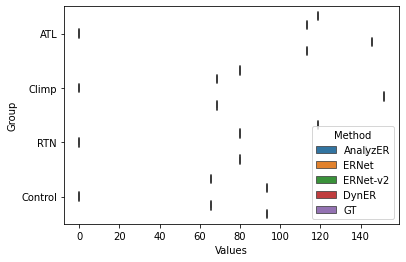

In [230]:
sns.boxplot(data=nodes, x='Values', y='Group', hue='Method')

In [236]:
df.to_csv('graph-comparison.csv')

In [237]:
df

,Method,Feature,Group,Replicate,Values
0,AnalyzER,Num_nodes,ATL,R1,118.800000
1,AnalyzER,Num_nodes,ATL,R2,80.100000
2,AnalyzER,Num_nodes,ATL,R3,118.666667
3,AnalyzER,Num_nodes,Climp,R1,65.800000
4,AnalyzER,Num_nodes,Climp,R2,59.400000
...,...,...,...,...,...
295,GT,Num_components,RTN,R2,5.400000
296,GT,Num_components,RTN,R3,6.000000
297,GT,Num_components,Control,R1,4.000000
298,GT,Num_components,Control,R2,3.900000


In [238]:
vals = df['Values']

In [244]:
# df[df['Method']== 'AnalyzER']

In [245]:
np.mean(vals[:12])

83.2074074074074

In [252]:
lt1 = []

for i in range(0, 60, 12):
    lt1.append(vals[i:i+12].mean())

In [253]:
lt1

[83.2074074074074,
 106.42954545454545,
 -0.07874054605724852,
 0.042588136404044706,
 1.0333333333333334]

In [254]:
lt2 = []
for i in range(60, 120, 12):
    lt2.append(vals[i:i+12].mean())

In [265]:
def get_mean(vals, a):
    lt = []
    for i in range(a-60, a, 12):
        lt.append(vals[i:i+12].mean())
    return lt

In [266]:
Analyzer = get_mean(vals, 60)

In [268]:
ernet = get_mean(vals, 120)

In [269]:
erv2 = get_mean(vals, 180)

In [270]:
nerdy = get_mean(vals, 240)

In [271]:
gt = get_mean(vals, 300)

In [272]:
Analyzer

[83.2074074074074,
 106.42954545454545,
 -0.07874054605724852,
 0.042588136404044706,
 1.0333333333333334]

In [273]:
ernet

[93.39907407407406,
 114.35454545454543,
 -0.05739739339212943,
 0.042935688529316236,
 3.677777777777777]

In [274]:
erv2

[76.98675000000001,
 76.65791666666668,
 -0.2306666666666667,
 0.016749999999999998,
 6.779916666666666]

In [275]:
nerdy

[146.21383333333333,
 162.4285,
 0.013500000000000003,
 0.026333333333333337,
 11.86425]

In [276]:
gt

[137.70725,
 179.45399999999998,
 0.04716666666666667,
 0.044000000000000004,
 6.393416666666667]

In [279]:
abs(gt[0] - nerdy[0]) / gt[0]

0.06177295192034798

In [286]:
def get_error(gt, method):
    err = []
    for i in range(5):
        val = abs(gt[i] - method[i]) / abs(gt[i])
        err.append(val)
    return err

In [287]:
analyzer_err = get_error(gt, Analyzer)

In [288]:
ernet_err = get_error(gt, ernet)

In [289]:
erv2_err = get_error(gt, erv2)

In [290]:
nerdy_err = get_error(gt, nerdy)

In [291]:
analyzer_err

[0.395765964338062,
 0.40692575560006766,
 2.6694108704717,
 0.03208780899898405,
 0.8383754122078702]

In [292]:
nvals = analyzer_err + ernet_err + erv2_err + nerdy_err

In [293]:
nvals

[0.395765964338062,
 0.40692575560006766,
 2.6694108704717,
 0.03208780899898405,
 0.8383754122078702,
 0.32175630495798824,
 0.36276402055933304,
 2.216905866970942,
 0.024188897060994728,
 0.4247554993634947,
 0.44093902100288823,
 0.5728269268633371,
 5.890459363957598,
 0.6193181818181819,
 0.060452809530636815,
 0.06177295192034798,
 0.09487389526006647,
 0.713780918727915,
 0.4015151515151515,
 0.85569791843172]

In [294]:
smalldf = pd.DataFrame()